# Model Spikey observed by *Kepler* with NymPyro

In this notebook we use the Bayesian inference package `NumPyro` (using MCMC and NUTS sampler) to model the Kepler observation of Spikey, reduced by Smith+2016. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Built-in
import sys
import copy

# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
# NumPyro
import numpyro
import numpyro.distributions as dist
from jax import numpy as jnp
# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)
import jax
from numpyro.infer import NUTS, MCMC

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

INFO:2026-03-26 16:40:28,868:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [3]:
# Define global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
c = 'mediumorchid'

---
## 1. Model Q
---

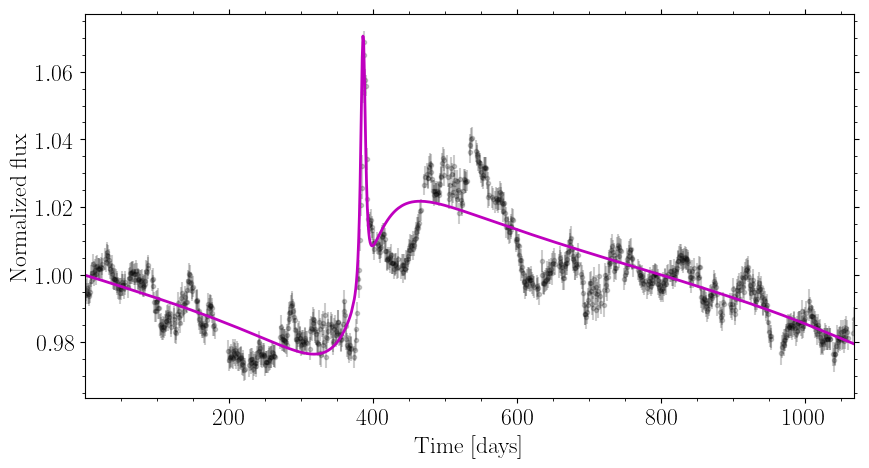

In [8]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_QDM_kepler_smith2016.csv')

# Create a binned light curve and plot
df = ut.bin_lc(df, bin_size=1)

# Convert to numpy for modelling
time = df.time.to_numpy()
flux = df.flux.to_numpy()
flux_err = df.flux_err.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Plot light curve
pt.plot_lc(df, dm, cm='m', alpha=0.2);

### 2.1. Free unit mean

In [9]:
# Define priors
priors = {
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    'mean' : dist.Normal(jnp.mean(flux), 0.5),
}

In [10]:
%%time
# Initialie NUTS kernel
nuts_kernel = NUTS(
    bs.make_tinygp_model(priors=priors, build_kernel=bs.drw_kernel), 
    target_accept_prob=0.9, 
    dense_mass=True, 
    max_tree_depth=5
)
# Initialise MCMC class
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)
# Run MCMC analysis
rng_key = jax.random.PRNGKey(params.seed)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mean      1.00      0.01      1.00      0.98      1.01   7991.41      1.00
     sigma      0.02      0.00      0.02      0.01      0.02   6722.96      1.00
       tau    147.94     81.18    125.73     55.25    247.48   6333.58      1.00

Number of divergences: 0
CPU times: user 8min 20s, sys: 8.42 s, total: 8min 28s
Wall time: 1min 37s


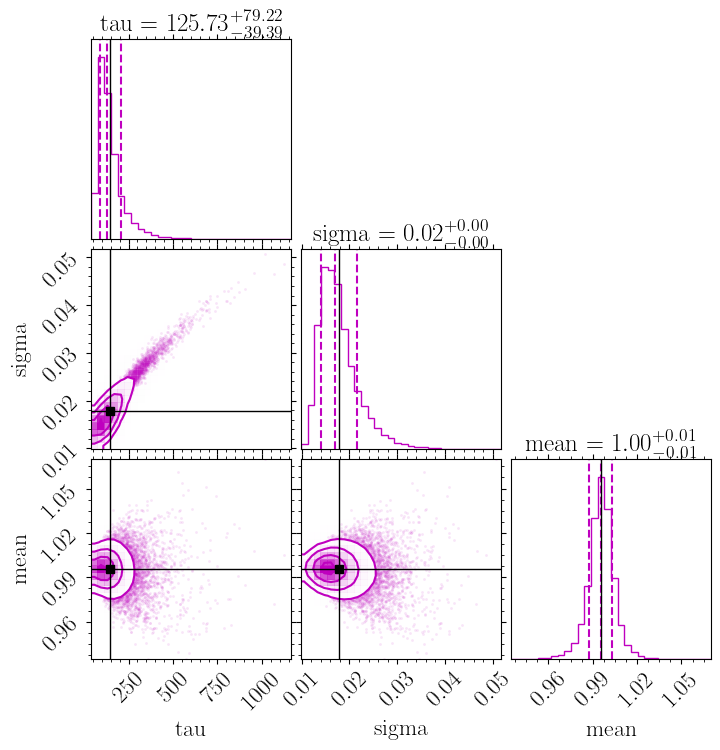

In [11]:
# Make corner plot
names  = ['tau', 'sigma', 'mean']
params = smbhb.model_params()
true_params = [1, params.sigma/1e3, params.tau]
fig = pt.plot_corner_mcmc(samples, names=names, color='m', true_params=true_params, bestfit='mean');
# fig.savefig(fdir / f'seminar_spikey_drw_corner.png', bbox_inches='tight', dpi=200)

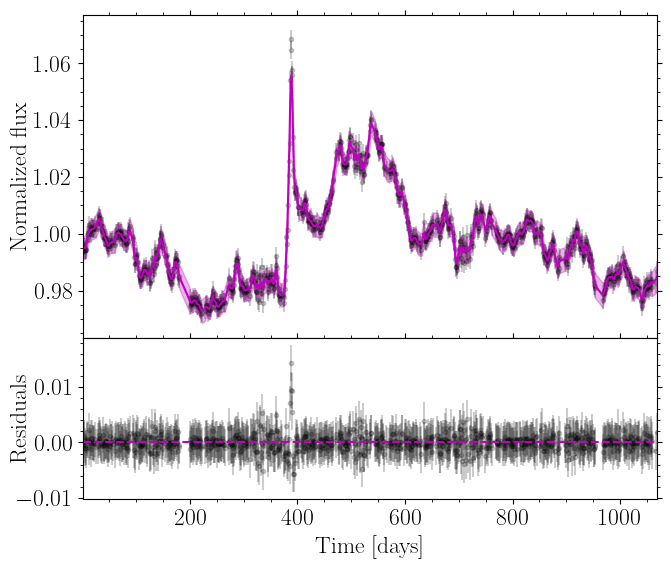

In [12]:
# Plot bestfit model
dm = bs.get_drw_lc(time, samples)
fig, ax = pt.plot_result(df, dm, samples=samples, cm='m', alpha=0.2, figsize=(7,6));
# fig.savefig(fdir / f'seminar_spikey_drw_bestfit.png', bbox_inches='tight', dpi=200)

### 2.2. Fixed SMBHB model (Spikey parameters)

In [13]:
priors = {
    'tau'  : dist.LogNormal(jnp.log(100.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}
spikey_params = {
    'z'    : params.z, 
    't0'   : params.t0, 
    'P'    : params.P, 
    'i'    : params.i, 
    'e'    : params.e, 
    'w'    : params.w,
    'L'    : params.L, 
    'alpha': params.alpha, 
    'vz'   : params.vz, 
    'logM1': params.logM1, 
    'logM2': params.logM2,
}

In [14]:
%%time
# Initialie NUTS kernel
nuts_kernel = NUTS(
    bs.make_tinygp_model(priors=priors | spikey_params, build_kernel=bs.drw_kernel, build_mean=bs.smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
# Initialise MCMC class
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)
# Run MCMC analysis
rng_key = jax.random.PRNGKey(params.seed)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

CPU times: user 28 ms, sys: 1 μs, total: 28 ms
Wall time: 27.4 ms


ValueError: vmap was requested to map its argument along axis 0, which implies that its rank should be at least 1, but is only 0 (its shape is ())

In [ ]:
# Make corner plot
names  = ['tau', 'sigma']
params = smbhb.model_params()
true_params = [params.sigma/1e3, params.tau]
fig = pt.plot_corner_mcmc(samples, names=names, color='m', true_params=true_params, bestfit='mean');
# fig.savefig(fdir / f'seminar_spikey_drw_corner2.png', bbox_inches='tight', dpi=200)

In [ ]:
# Get DRW model and plot along with data
dm = bs.get_drw_lc(time, samples)
fig, ax = pt.plot_result(df, dm, samples=samples, cm='m', alpha=0.2, figsize=(7,6));
# fig.savefig(fdir / f'seminar_spikey_drw_bestfit2.png', bbox_inches='tight', dpi=200)

### 2.3. Fitting DRW + fixed SMBHB model (wrong parameters)

In [ ]:
# Set wrong eccentricity
spikey_params_wrong = spikey_params.copy()
spikey_params_wrong['e'] = 0.0

In [ ]:
%%time
# Initialie NUTS kernel
nuts_kernel = NUTS(
    bs.make_tinygp_model(priors=priors | spikey_params_wrong, build_kernel=bs.drw_kernel, build_mean=bs.smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
# Initialise MCMC class
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)
# Run MCMC analysis
rng_key = jax.random.PRNGKey(params.seed)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

In [ ]:
# Make corner plot
names  = ['tau', 'sigma']
params = smbhb.model_params()
true_params = [params.sigma/1e3, params.tau]
fig = pt.plot_corner_mcmc(samples, names=names, color='m', true_params=true_params, bestfit='mean');
# fig.savefig(fdir / f'seminar_spikey_drw_corner3.png', bbox_inches='tight', dpi=200)

In [ ]:
# Get DRW model and plot along with data
dm = bs.get_drw_lc(time, samples)
fig, ax = pt.plot_result(df, dm, samples=samples, cm='m', alpha=0.2, figsize=(7,6));
# fig.savefig(fdir / f'seminar_spikey_drw_bestfit3.png', bbox_inches='tight', dpi=200)

### Conclusion

- DRW is perfectly capable of fitting the full time series.
- As shown before, it does not really matter if the SMBHB model is "wrong", the DRW can compensate.
- With the SMBHB model as mean, DRW variance and time scale are smaller than in the previous case.

---
## 2. Model DM
---

In [ ]:
filename = 'spikey_kepler_QDM_bin1d_numpyro_uniform'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}

In [ ]:
%%time

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=None, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

In [ ]:
# %%time
# result = bs.run_numpyro(df, params, priors, bs.smbhb_mean_builder, num_samples=1_000)

In [ ]:
result

In [ ]:
# dm = smbhb.model_lightcurve(time, result['posterior']['map'])
# fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3, figsize=(9,7));
# # fig.savefig(rdir / filename / 'plots' / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)

In [ ]:
# fig = pt.plot_corner(result, best_params='map', true_params=true_params, color=c);
# # fig.savefig(rdir / filename / 'plots' / f'{filename}_corner.png', bbox_inches='tight', dpi=200);

In [ ]:
# corner_plot(samples, true_params=spikey_params)

# fig, ax = plt.subplots(figsize=(9, 5))
# ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-1)
# # predictive_posterior(ax, x=time, samples=samples)
# ax.plot(time_interp, samples['pred_smbhb'].mean(axis=0))

# # Let's also plot the mean value
# spikey_params = {
#     'z': 0.918, 
#     't0': samples['t0'].mean(), 
#     'P': samples['P'].mean(), 
#     'i': samples['i'].mean(), 
#     'e': samples['e'].mean(), 
#     'w': samples['w'].mean(),
#     'L': samples['L'].mean(), 
#     'alpha': samples['alpha'].mean(), 
#     'vz': 0, 
#     'logM1': samples['logM1'].mean(), 
#     'logM2': samples['logM2'].mean(),
# }

# smbhb_partial = partial(smbhb_two_masses, **spikey_params)
# sim_flux = jax.vmap(smbhb_partial)(time)
# ax.plot(time, sim_flux);

---
## 3. Model QDM
---

In [ ]:
filename = 'spikey_kepler_QDM_bin1d_numpyro_uniform'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
    'tau'  : dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}

In [ ]:
%%time

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)
corner_plot(samples, true_params=spikey_params)

### 3.2. Constrained DRW parameters

In [ ]:
filename = 'spikey_kepler_1d_numpyro'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
    'tau'  : 21,
    'sigma': 0.01,
}

In [ ]:
%%time

priors = {
    'logM1': dist.Uniform(6, 11),
    'logM2': dist.Uniform(6, 11),
    'L': dist.Uniform(0, 1),
    'e': dist.Uniform(0, 1),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
    'tau': 21,
    'sigma': 0.01,
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

In [ ]:
corner_plot(samples, true_params=spikey_params)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-1)
predictive_posterior(ax, x=time_interp, samples=samples)